# 1.3.2 延迟怎样改变调节

## 学习目标与先修知识

- 按给定规则读取历史信息，解释延迟（delay）。
- 在公平对照中辨认过冲（overshoot）与转向。
- 将有限轨迹（trajectory）的观察与任意长时间的保证区分开。

**先修知识**：[作用方向与反馈回路](01-作用方向与反馈回路.ipynb)；列表索引、绝对值、循环。

## 具体问题

一个人工调节器每隔一段固定时间修正温度偏差。当前偏差为 2 °C；每次按所读取偏差的一半作反向修正。如果读数来自两步以前，而过去一直为 2 °C，最初三次会怎样？

先只比较前两步：即时读取第二次看到的是 1，延迟读取第二次仍看到 2。各组使用同一起点和同一作用强度。偏差可以是负数，意思是低于目标，并不是绝对温度小于零。

In [1]:
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
immediate_first = 2 - 0.5*2
immediate_second = immediate_first - 0.5*immediate_first
delayed_first = 2 - 0.5*2
delayed_second = delayed_first - 0.5*2
display(Markdown(show_table(['组别', '第 1 步 / °C', '第 2 步 / °C'],
                           [('即时', immediate_first, immediate_second), ('两步延迟', delayed_first, delayed_second)])))

| 组别 | 第 1 步 / °C | 第 2 步 / °C |
| --- | --- | --- |
| 即时 | 1 | 0.5 |
| 两步延迟 | 1 | 0 |

## 模型假设

温度偏差 e 是相对目标的差，单位 °C。每步取固定长度的观察间隔；增益（gain）是一个无量纲（dimensionless）的教学比例，即单位为 1。读旧值的步数 d 为 0、1 或 2。

我们明确指定时刻 −d 到 0 的全部历史偏差；仅给当前值还不够执行延迟规则。默认历史恒为 2 °C，gain=0.5，观察 12 步。规则忽略噪声、外部扰动、执行器限幅及空间差异。

负反馈（negative feedback）的方向在所有组相同：所读取偏差为正就减小当前值，为负就增大当前值。两组只改变信息年龄，历史、起点、强度和观察步数保持一致。

## 数学解释与推导

把一次操作写清楚即可：

**新偏差 = 当前偏差 − gain × d 步以前的偏差。**

`history` 按从早到晚排列，最后一项为时刻 0。在添加新值前，`values[-1]` 是当前值，`values[-1-d]` 是 d 步前的值。

当 d=2 时，前 3 次使用的都是 2，得到 1、0、−1。第 4 次使用时刻 1 的值 1，得到 −1.5。穿过目标零线称为过冲。

为了比较曲线，另算两个描述量：最大绝对偏差、转向次数。转向用相邻增量的正负号切换来计数；忽略绝对值不超过 $10^{-12}$ 的零增量，避免平台被算成一次新方向。这是明确的统计约定，不是控制稳定性的判据。

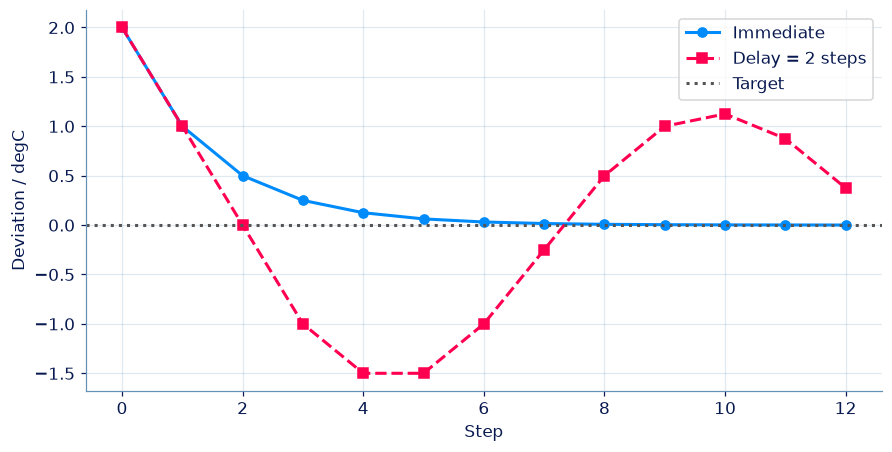

In [2]:
def response(history, gain, delay, steps):
    values = list(history)
    for _ in range(steps):
        correction = gain*values[-1-delay]
        values.append(values[-1]-correction)
    return values[delay:]  # 只返回时刻 0 以后的轨迹，包含起点

def describe(path):
    differences = [b-a for a,b in zip(path,path[1:])]
    directions = [1 if v>0 else -1 for v in differences if abs(v)>1e-12]
    turns = sum(a!=b for a,b in zip(directions,directions[1:]))
    return max(abs(v) for v in path), turns

immediate = response([2], .5, 0, 12)
delayed = response([2,2,2], .5, 2, 12)
assert immediate[:4] == [2,1,.5,.25]
assert delayed[:9] == [2,1,0,-1,-1.5,-1.5,-1,-.25,.5]
fig, ax = plt.subplots()
ax.plot(range(13), immediate, 'o-', label='Immediate')
ax.plot(range(13), delayed, 's--', label='Delay = 2 steps')
ax.axhline(0, color='#555555', ls=':', label='Target')
ax.set(xlabel='Step', ylabel='Deviation / degC')
ax.legend()
plt.show()

## 对照实验

先保留全部 12 步，把 gain 从 0.5 改为 0.2，其他条件不变。再用同一个函数检查零作用和零步数，确认列表没有偷用未来值。不要只挑选最好看的片段。

In [3]:
rows=[]
for gain in [.2,.5]:
    for delay in [0,2]:
        path=response([2]*(delay+1),gain,delay,12)
        max_abs, turns=describe(path)
        rows.append([gain,delay,path[-1],max_abs,turns])
display(Markdown(show_table(['gain', '延迟 / 步', '终点 / °C', '最大绝对偏差 / °C', '转向 / 次'],rows)))
assert response([2,2,2],0,2,3) == [2,2,2,2]
assert response([3,2,1],.5,2,0) == [1]
assert describe([2,1,1,2,2,0]) == (2,2)

| gain | 延迟 / 步 | 终点 / °C | 最大绝对偏差 / °C | 转向 / 次 |
| --- | --- | --- | --- | --- |
| 0.2 | 0 | 0.137439 | 2 | 0 |
| 0.2 | 2 | -0.048 | 2 | 1 |
| 0.5 | 0 | 0.000488281 | 2 | 0 |
| 0.5 | 2 | 0.375 | 2 | 2 |

## 结果解释

gain=0.5、两步延迟时，前几步调节仍在响应过去的正偏差，因此当前值到零后继续下降。随后负的旧信息又会令修正方向反转。负反馈的符号没有变，轨迹却不再单调。

在相同历史和观察窗下，延迟与调节强度改变了轨迹：过冲反映越过目标的程度，最大绝对偏差反映最远偏离，转向次数反映来回变化。把这些量与终点一起看，才能解释调节过程。

[打开可视化与探索：反馈延迟与层级](http://127.0.0.1:8000/chapters/01-03-反馈、延迟与层级/explore/)

[本章导览](http://127.0.0.1:8000/chapters/01-03-反馈、延迟与层级/)

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：第一步使用哪一个历史值

温度偏差（deviation）规则为“新偏差 = 当前偏差 − gain×delay 步以前的偏差”。history 按从早到晚给出 −delay 到 0 的值。delay=2、history=[3,2,1]、gain=0.5 时，第一步是多少？

- **A.** 0.5
- **B.** −0.5
- **C.** 1.5
- **D.** −1

[作答：第一步使用哪一个历史值](http://127.0.0.1:8000/chapters/01-03-%E5%8F%8D%E9%A6%88%E3%80%81%E5%BB%B6%E8%BF%9F%E4%B8%8E%E5%B1%82%E7%BA%A7/practice/?question=p01-delay-history)

### 第 2 题 · Python 计算题：让调节读取过去的信息

给定人工温度偏差规则及延迟（delay），返回从时刻 0 起的轨迹（trajectory）、最大绝对偏差和转向次数。偏差可正可负；它不是绝对温度。

**函数与代码模板**

```python
def solve(
    history: list[float],
    gain: float,
    delay: int,
    steps: int,
) -> tuple[list[float], float, int]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `history` | `list[float]` | 从时刻 −delay 到 0 的已知偏差；最后一项是起点。 | °C |
| `gain` | `float` | 每次调节使用过去偏差的比例。 | 无量纲 |
| `delay` | `int` | 读取多少步以前的信息。 | 步 |
| `steps` | `int` | 从时刻 0 向后更新的步数。 | 步 |

**返回值**

按以下顺序返回元组：(trajectory, max_abs, turns)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `trajectory` | `list[float]` | 时刻 0 到 steps 的偏差；不含负时刻历史。 | °C |
| `max_abs` | `float` | 返回轨迹中绝对值的最大值，包含起点。 | °C |
| `turns` | `int` | 相邻非零增量方向改变的次数。 | 次 |

**计算规则**

每步：新偏差 = 当前偏差 − gain×delay 步以前的偏差。计算返回轨迹的相邻增量；绝对值 ≤ 1e−12 的增量视作零并忽略，其余增量的正负号相邻改变一次记一次转向。

**约束与边界**

- 所有数值均为有限数。
- delay 为 0、1、2；len(history)=delay+1；history 每项绝对值 ≤ 10。
- 0 ≤ gain ≤ 1；0 ≤ steps ≤ 100；返回长度 steps+1。
- 不把负时刻到 0 的变化计入转向次数；steps=0 时 turns=0。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| history | 从时刻 −delay 到 0 的已知偏差；最后一项是起点。 | [2, 2, 2] | °C |
| gain | 每次调节使用过去偏差的比例。 | 0.5 | 无量纲 |
| delay | 读取多少步以前的信息。 | 2 | 步 |
| steps | 从时刻 0 向后更新的步数。 | 4 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
history = [2, 2, 2]
gain = 0.5
delay = 2
steps = 4

result = solve(history, gain, delay, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| trajectory | 时刻 0 到 steps 的偏差；不含负时刻历史。 | [2, 1, 0, -1, -1.5] | °C |
| max_abs | 返回轨迹中绝对值的最大值，包含起点。 | 2 | °C |
| turns | 相邻非零增量方向改变的次数。 | 0 | 次 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([2, 1, 0, -1, -1.5], 2, 0)
```

**样例解释**

前 3 次都读取偏差 2，依次得到 1、0、−1；第 4 次读取时刻 1 的偏差 1，得到 −1.5。轨迹一直下降，因此尚无转向。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：让调节读取过去的信息](http://127.0.0.1:8000/chapters/01-03-%E5%8F%8D%E9%A6%88%E3%80%81%E5%BB%B6%E8%BF%9F%E4%B8%8E%E5%B1%82%E7%BA%A7/practice/?question=p01-delayed-response)

### 第 3 题 · 单项选择题：怎样只比较延迟

要用人工温度规则研究延迟（delay）的作用。即时组和两步延迟组怎样设置最合理？

- **A.** 同时改变起点、gain、观察长度和延迟。
- **B.** 起点同为 2，历史恒为 2，gain 和更新次数相同，只改变读取信息的延迟。
- **C.** 即时组观察 2 步，延迟组观察 100 步。
- **D.** 每次挑选看起来最平滑的一段轨迹（trajectory）。

[作答：怎样只比较延迟](http://127.0.0.1:8000/chapters/01-03-%E5%8F%8D%E9%A6%88%E3%80%81%E5%BB%B6%E8%BF%9F%E4%B8%8E%E5%B1%82%E7%BA%A7/practice/?question=p01-fair-delay)

### 第 4 题 · Python 计算题：平台之后算一次转向

给定已经计算好的偏差轨迹（trajectory），统计方向改变次数。连续不变的平台不产生新方向；平台前后由升转降或由降转升才计一次。

**函数与代码模板**

```python
def solve(
    values: list[float],
) -> int:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `values` | `list[float]` | 从早到晚的偏差。 | °C |

**返回值**

直接返回 turns（int）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `turns` | `int` | 去掉零增量后，增量符号相邻变化的次数。 | 次 |

**计算规则**

计算相邻差值；绝对值 ≤ 1e−12 视作零。忽略这些零，再统计正负号切换。

**约束与边界**

- 所有数值均为有限数。
- 1 ≤ len(values) ≤ 1000；每项绝对值 ≤ 1000。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| values | 从早到晚的偏差。 | [2, 1, 1, 2, 2, 0] | °C |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
values = [2, 1, 1, 2, 2, 0]

result = solve(values)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| turns | 去掉零增量后，增量符号相邻变化的次数。 | 2 | 次 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = 2
```

**样例解释**

非零增量依次为 −1、+1、−2，符号从负到正、正到负，共两次。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：平台之后算一次转向](http://127.0.0.1:8000/chapters/01-03-%E5%8F%8D%E9%A6%88%E3%80%81%E5%BB%B6%E8%BF%9F%E4%B8%8E%E5%B1%82%E7%BA%A7/practice/?question=p01-turn-count)

### 第 5 题 · 多项选择题：八步实验的结论范围

在 gain=0.5 的人工规则下，两步延迟（delay）轨迹（trajectory）越过目标，而即时组未越过。以下哪些结论有依据？

- **A.** 这组条件下的延迟对照出现不同轨迹。
- **B.** 所有人体调节都必须取 gain=0.5。
- **C.** 只需八步就证明任意长时间都不会再增长。
- **D.** 负反馈（negative feedback）的方向不能单独保证单调接近目标。

[作答：八步实验的结论范围](http://127.0.0.1:8000/chapters/01-03-%E5%8F%8D%E9%A6%88%E3%80%81%E5%BB%B6%E8%BF%9F%E4%B8%8E%E5%B1%82%E7%BA%A7/practice/?question=p01-finite-path)

**进一步阅读**

[MIT 15.871 Assignment 3](https://ocw.mit.edu/courses/15-871-introduction-to-system-dynamics-fall-2013/b950bd7b4f565b7b19145fb16bd55c8e_MIT15_871F13_ass3.pdf)：A—B 部分辨认量、边界及物质连接，C 部分讨论积累，D 部分讨论目标调节。本节数值和代码是独立设计的教学例子。